In [1]:
import xarray as xr
import numpy as np
from datetime import datetime
from calendar import monthrange
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import random
from datetime import datetime
import metpy
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13
})

/opt/miniconda3/lib/python3.9/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
sfno = xr.open_zarr("/pscratch/sd/a/amahesh/hens/time_collection/bred_29multicheckpoint_pert0p35_k1i3_500km_oppositepert_detfix_nodpr_timeevolve_hemisphererescale_target48_20minus20_newseed_repeat_qperturbfix_rankhist_qmin0_summer2023/2023-06-27T00:00:00/ensemble.zarr")
sfno

<xarray.Dataset> Size: 15GB
Dimensions:  (lat: 721, lon: 1440, ensemble: 58, time: 61)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 488B 2023-06-27 ... 2023-07-12
Dimensions without coordinates: ensemble
Data variables:
    t2m      (ensemble, time, lat, lon) float32 15GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.10
    config:                 {"weather_model": "dummy_model", "simulation_leng...
    date_created:           2024-05-04T15:19:58.225260
    history:                /global/u2/a/amahesh/hens/earth2mip/earth2mip/tim...
    institution:            NVIDIA
    model:                  dummy_model
    model_str:              None
    time_averaging_window:  
    weather_event:          {"properties": {"name": "global", "start_time": "...

In [4]:
kc_lat, kc_lon = 33.5, 360-112

true = xr.open_dataset("/pscratch/sd/p/pharring/74var-6hourly/staging/2023.h5", mode='r')
dummy = xr.open_dataset("/dvs_ro/cfs/cdirs/m1517/cascade/amahesh/hens/HENS_summer23_20230814T000000/ensemble_out_00001_2023-08-14-00-00-00.nc",
                       group='global')

true = true.rename({'phony_dim_0' : 'time',
                    'phony_dim_2' : 'lat', 
             'phony_dim_3' : 'lon',
             'phony_dim_1' : 'channel'})
true['lat'] = dummy['lat']
true['lon'] = dummy['lon']
true['channel'] = ["u10m", "v10m", "u100m", "v100m", "t2m", "sp", "msl", "tcwv", "d2m", "u50", "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000", "v50", "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000", "z50", "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000", "t50", "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000", "q50", "q100", "q150", "q200", "q250", "q300", "q400", "q500", "q600", "q700", "q850", "q925", "q1000"]
true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')

true_kc = true.sel(lat=kc_lat, lon=kc_lon, channel=['t2m', 'd2m'])

true_kc = true_kc['fields'].to_dataset("channel")

/tmp/ipykernel_651736/2460466221.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


(307.0, 321.0)

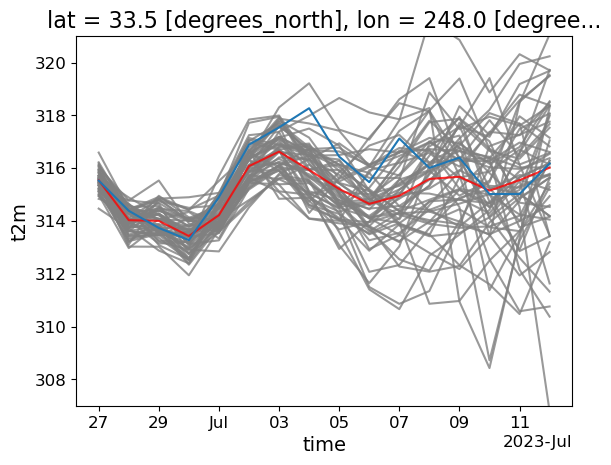

In [155]:
for i in range(58):
    sfno.sel(ensemble=i, lat=kc_lat, lon=kc_lon)['t2m'].resample(time='D').max().plot(color='gray',alpha=0.8)
sfno.sel(lat=kc_lat, lon=kc_lon).mean('ensemble')['t2m'].resample(time='D').max().plot(color='red',alpha=0.8)
true_kc.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot()
plt.ylim(307,321)

In [20]:
ifs = xr.open_dataset("/pscratch/sd/a/amahesh/tigge/d2m_t2m_summer23/postprocessed/ifs_ens_forecast_2023-06-27_postprocessed_t2m_d2m_heat-index.nc")
ifs = ifs.assign_coords({'step' : ifs['time'].values + ifs['step'].values}).rename({'time' : 'initial_time'}).rename({'step' : 'time'})
ifs

<xarray.Dataset> Size: 51GB
Dimensions:            (initial_time: 1, number: 50, latitude: 721,
                        longitude: 1440, time: 61)
Coordinates:
  * initial_time       (initial_time) datetime64[ns] 8B 2023-06-27
  * number             (number) int64 400B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    heightAboveGround  float64 8B ...
    valid_time         (time) datetime64[ns] 488B ...
  * time               (time) datetime64[ns] 488B 2023-06-27 ... 2023-07-12
Data variables:
    heat_index         (initial_time, number, time, latitude, longitude) float64 25GB ...
    t2m                (number, time, latitude, longitude) float32 13GB ...
    d2m                (number, time, latitude, longitude) float32 13GB ...

(307.0, 321.0)

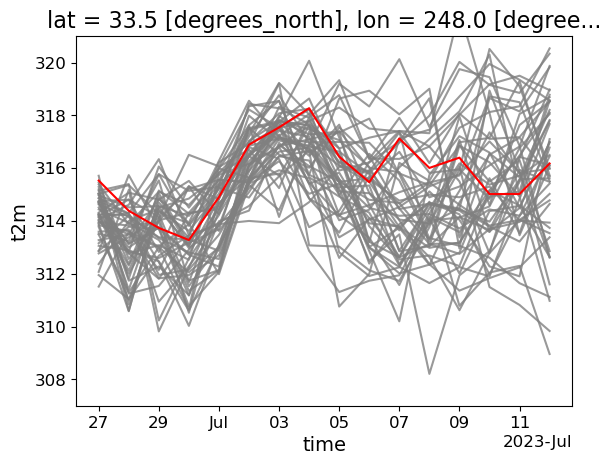

In [157]:
ifs_kc = ifs.sel(latitude=kc_lat, longitude=kc_lon)
for i in range(50):
    ifs_kc.isel(number=i)['t2m'].resample(time='D').max().plot(color='gray', alpha=0.8)
true_kc.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot(color='red')

plt.ylim(307,321)

In [21]:
analysis = xr.open_dataset("/pscratch/sd/a/amahesh/tigge/analysis/ifs_analysis-2023-06.grib")
analysis2 = xr.open_dataset("/pscratch/sd/a/amahesh/tigge/analysis/ifs_analysis-2023-07.grib")
analysis = xr.concat([analysis, analysis2], dim='time')
analysis = analysis[['t2m', 'd2m']]
analysis = analysis.sel(latitude=kc_lat, longitude=kc_lon)

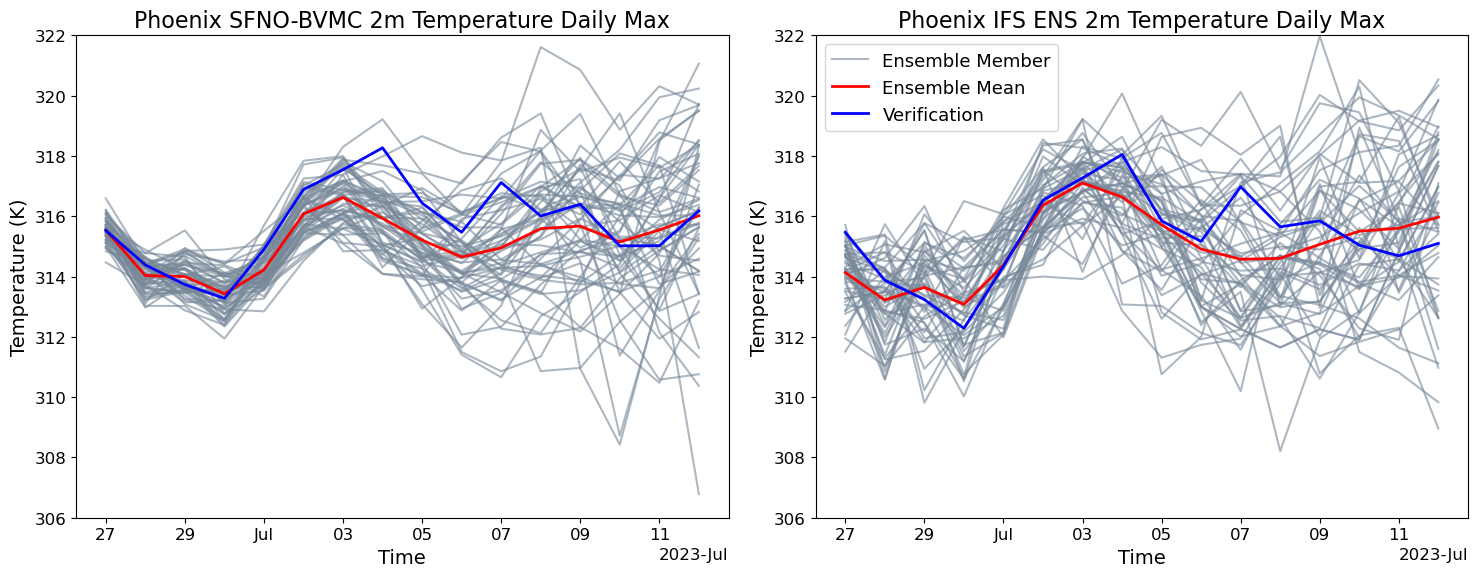

In [23]:
import matplotlib.pyplot as plt

# Create the figure with 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))  # Adjust figsize as needed

# First subplot for SFNO data
kc_lat, kc_lon = 33.5, 360-112
for i in range(58):
    sfno.sel(ensemble=i, lat=kc_lat, lon=kc_lon)['t2m'].resample(time='D').max().plot(ax=ax[0], color='lightslategray', alpha=0.6)
sfno.sel(lat=kc_lat, lon=kc_lon).mean('ensemble')['t2m'].resample(time='D').max().plot(ax=ax[0], color='red', linewidth=2)
true_kc.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot(ax=ax[0], color='blue', linewidth=2)

ax[0].set_ylim(306, 322)
ax[0].set_title("Phoenix SFNO-BVMC 2m Temperature Daily Max".format(kc_lat, kc_lon))
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Temperature (K)")

# Second subplot for IFS data
ifs_kc = ifs.sel(latitude=kc_lat, longitude=kc_lon)
for i in range(50):
    if i == 0:
        ifs_kc.isel(number=i)['t2m'].resample(time='D').max().plot(ax=ax[1], color='lightslategray', alpha=0.6, label='Ensemble Member')
    ifs_kc.isel(number=i)['t2m'].resample(time='D').max().plot(ax=ax[1], color='lightslategray', alpha=0.6,)
ifs_kc.mean('number')['t2m'].resample(time='D').max().plot(ax=ax[1], color='red', linewidth=2, label='Ensemble Mean')
analysis.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot(ax=ax[1], color='blue',linewidth=2, label='Verification')

ax[1].set_ylim(306, 322)
ax[1].set_title("Phoenix IFS ENS 2m Temperature Daily Max".format(kc_lat, kc_lon))
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Temperature (K)")
ax[1].legend()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('phoenix_henspart1.pdf')
# Show the plot
plt.show()


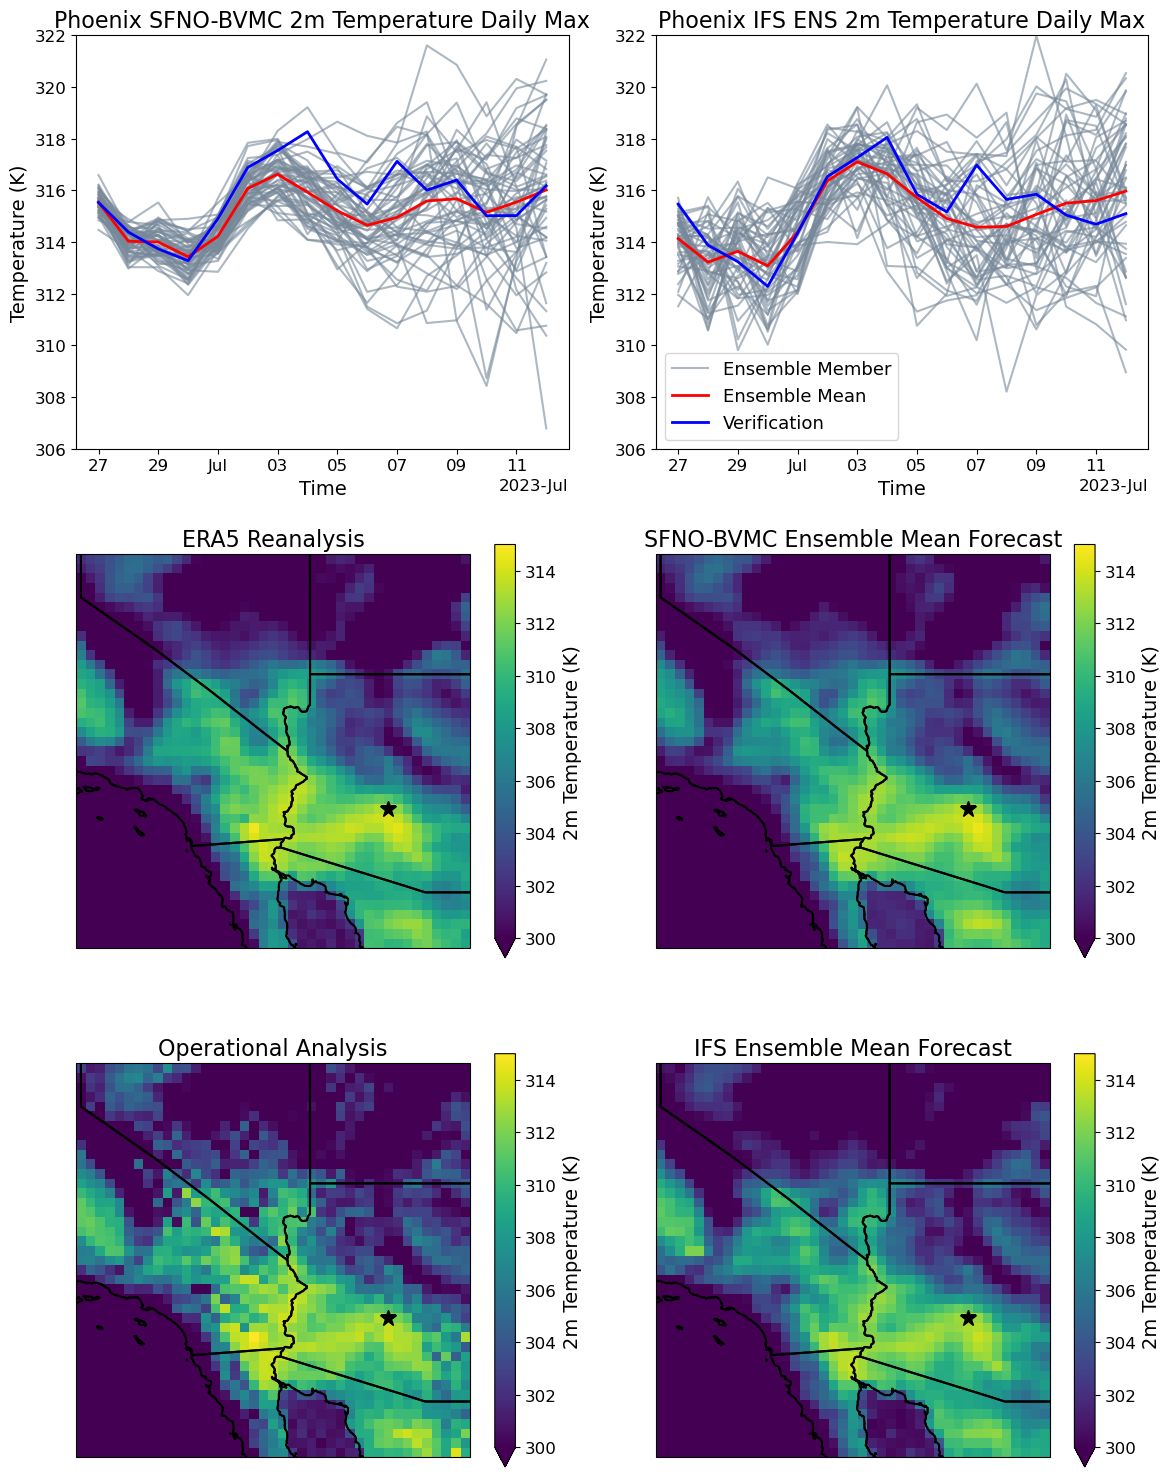

In [71]:
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

# Create the figure with 3x2 subplots (3 rows, 2 columns)
fig, ax = plt.subplots(3, 2, figsize=(12, 15))  # Adjust figsize as needed
ax = ax.flatten()  # Flatten the 2D ax array for easy indexing

# Set the background of all axes to be transparent (no square background)
for a in ax[2:]:
    a.set_facecolor('none')
    a.spines['top'].set_visible(False)  # Remove top spine
    a.spines['right'].set_visible(False)  # Remove right spine
    a.spines['left'].set_visible(False)  # Remove left spine
    a.spines['bottom'].set_visible(False)  # Remove bottom spine
    a.set_xticks([])  # Remove x-axis ticks
    a.set_yticks([])  # Remove y-axis ticks

# First subplot for SFNO data
kc_lat, kc_lon = 33.5, 360 - 112
for i in range(58):
    sfno.sel(ensemble=i, lat=kc_lat, lon=kc_lon)['t2m'].resample(time='D').max().plot(ax=ax[0], color='lightslategray', alpha=0.6)
sfno.sel(lat=kc_lat, lon=kc_lon).mean('ensemble')['t2m'].resample(time='D').max().plot(ax=ax[0], color='red', linewidth=2)
true_kc.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot(ax=ax[0], color='blue', linewidth=2)

ax[0].set_ylim(306, 322)
ax[0].set_title("Phoenix SFNO-BVMC 2m Temperature Daily Max")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Temperature (K)")

# Second subplot for IFS data
ifs_kc = ifs.sel(latitude=kc_lat, longitude=kc_lon)
for i in range(50):
    if i == 0:
        ifs_kc.isel(number=i)['t2m'].resample(time='D').max().plot(ax=ax[1], color='lightslategray', alpha=0.6, label='Ensemble Member')
    else:
        ifs_kc.isel(number=i)['t2m'].resample(time='D').max().plot(ax=ax[1], color='lightslategray', alpha=0.6)

ifs_kc.mean('number')['t2m'].resample(time='D').max().plot(ax=ax[1], color='red', linewidth=2, label='Ensemble Mean')
analysis.sel(time=sfno['time'])['t2m'].resample(time='D').max().plot(ax=ax[1], color='blue', linewidth=2, label='Verification')

ax[1].set_ylim(306, 322)
ax[1].set_title("Phoenix IFS ENS 2m Temperature Daily Max")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Temperature (K)")
ax[1].legend()

# Third subplot for ERA5 Reanalysis (Map)
ax[2] = plt.subplot(3, 2, 3, projection=ccrs.PlateCarree())
true['fields'].to_dataset("channel")['t2m'].sel(time='2023-06-30').resample(time='D').max().sel(lat=slice(40, 30),
                                                                                                lon=slice(360 - 120, 360 - 110)).plot(
    vmin=300, vmax=315, ax=ax[2], transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': '2m Temperature (K)'})
ax[2].coastlines()
ax[2].add_feature(cfeature.STATES, zorder=1, linewidth=1.5, edgecolor='black')
ax[2].set_title("ERA5 Reanalysis")
ax[2].plot(lon_star, lat_star, marker='*', color='black', markersize=12, transform=ccrs.PlateCarree(), label="Red Star (33.5, 248)")

# Fourth subplot for SFNO-BVMC Ensemble Mean Forecast (Map)
ax[3] = plt.subplot(3, 2, 4, projection=ccrs.PlateCarree())
sfno['t2m'].sel(lat=slice(40, 30), lon=slice(360 - 120, 360 - 110)).sel(time='2023-06-30').mean('ensemble').resample(time='D').max().plot(
    vmin=300, vmax=315, ax=ax[3], transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': '2m Temperature (K)'})
ax[3].coastlines()
ax[3].add_feature(cfeature.STATES, zorder=1, linewidth=1.5, edgecolor='black')
ax[3].add_feature(cfeature.COASTLINE)
ax[3].set_title("SFNO-BVMC Ensemble Mean Forecast")
ax[3].plot(lon_star, lat_star, marker='*', color='black', markersize=12, transform=ccrs.PlateCarree(), label="Red Star (33.5, 248)")

# Fifth subplot for IFS Ensemble Mean Forecast (Map)
ax[5] = plt.subplot(3, 2, 6, projection=ccrs.PlateCarree())
ifs['t2m'].sel(latitude=slice(40, 30), longitude=slice(360 - 120, 360 - 110)).sel(time='2023-06-30').mean('number').resample(time='D').max().plot(
    vmin=300, vmax=315, ax=ax[5], transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': '2m Temperature (K)'})
ax[5].coastlines()
ax[5].add_feature(cfeature.STATES, zorder=1, linewidth=1.5, edgecolor='black')
ax[5].add_feature(cfeature.COASTLINE)
ax[5].set_title("IFS Ensemble Mean Forecast")
ax[5].plot(lon_star, lat_star, marker='*', color='black', markersize=12, transform=ccrs.PlateCarree(), label="Red Star (33.5, 248)")

# Sixth subplot for Operational Analysis (Map)
ax[4] = plt.subplot(3, 2, 5, projection=ccrs.PlateCarree())
analysis_vis = xr.open_dataset("/pscratch/sd/a/amahesh/tigge/analysis/ifs_analysis-2023-06.grib")
analysis_vis['t2m'].sel(latitude=slice(40, 30), longitude=slice(360 - 120, 360 - 110)).sel(time='2023-06-30').resample(time='D').max().plot(
    vmin=300, vmax=315, ax=ax[4], transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': '2m Temperature (K)'})
ax[4].coastlines()
ax[4].set_title("Operational Analysis")
ax[4].add_feature(cfeature.STATES, zorder=1, linewidth=1.5, edgecolor='black')
ax[4].add_feature(cfeature.COASTLINE)
ax[4].plot(lon_star, lat_star, marker='*', color='black', markersize=12, transform=ccrs.PlateCarree(), label="Red Star (33.5, 248)")

# Adjust layout to avoid overlap
plt.tight_layout()

# Optionally save the plot to a file
# plt.savefig('phoenix_henspart1.pdf')

# Show the plot
plt.show()
